# Feature Extraction Pipeline\n\nLoads the raw vase contours, visualises a sample, runs `feature_extraction_function.py` across every vase, and writes out a single parquet file: one row per vase, every metadata/demographic column from the raw game data, plus the 19 phenotypic features defined in `vase_features_master.xlsx`. The raw `x`/`y` point columns are dropped from the output — everything else from the source data is kept as-is.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "feature_extraction" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "feature_extraction"))

import feature_extraction_function as fef

XY_PATH = PROJECT_ROOT / "file_processing" / "processed" / "xy_data.parquet"
PC_PATH = PROJECT_ROOT / "file_processing" / "processed" / "pc_data.parquet"
OUT_PATH = PROJECT_ROOT / "feature_extraction" / "outdir" / "vase_phenotype_features.parquet"
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

GROUP_KEYS = ["participant_id", "generation_key", "vase"]

## 1. Load data

`xy_data.parquet` is point-level: ~250 rows per vase (the closed, mirrored contour), with every metadata/demographic column repeated on each point row. `pc_data.parquet` is long-format PCA scores (one row per vase per PC); it's only needed for the `distance_from_pc_centroid` feature and is deduplicated here per the known double-ingestion issue in that file.

In [2]:
xy_df = pd.read_parquet(XY_PATH)
print(f"xy_data: {len(xy_df):,} point rows, {xy_df.groupby(GROUP_KEYS).ngroups:,} vases")
xy_df.head()

xy_data: 34,050,000 point rows, 136,200 vases


,generation_key,vase,x,y,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_status,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status
0,round_0_gen_1,vase_1,0.000650,1.977799,True,False,7.435,7435,7.427,7427.0,...,completed,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed
1,round_0_gen_1,vase_1,0.046236,1.977766,True,False,7.435,7435,7.427,7427.0,...,completed,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed
2,round_0_gen_1,vase_1,0.091811,1.977784,True,False,7.435,7435,7.427,7427.0,...,completed,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed
3,round_0_gen_1,vase_1,0.137535,1.977849,True,False,7.435,7435,7.427,7427.0,...,completed,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed
4,round_0_gen_1,vase_1,0.183402,1.978020,True,False,7.435,7435,7.427,7427.0,...,completed,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed


In [3]:
# pc_data.parquet is known to have 13 sessions ingested twice (see project memory) —
# drop_duplicates before any per-vase lookup. Pivot long -> wide (PC1..PC6) and
# collapse to one Euclidean-norm value per vase up front, rather than carrying
# 6 raw PC columns through the rest of the pipeline.
pc_df = pd.read_parquet(PC_PATH, columns=["generation_key", "vase", "pc_name", "pc_value", "participant_id"])
pc_df = pc_df.drop_duplicates(subset=["participant_id", "generation_key", "vase", "pc_name"])

pc_wide = pc_df.pivot_table(index=GROUP_KEYS, columns="pc_name", values="pc_value", aggfunc="first")
pc_cols = [c for c in pc_wide.columns if c.startswith("PC")]
pc_centroid_distance = np.sqrt((pc_wide[pc_cols] ** 2).sum(axis=1)).rename("distance_from_pc_centroid")

hubner_line4_x = fef.load_hubner_line4(str(PROJECT_ROOT / "feature_extraction" / "hubner_lines_0326" / "line4_standardised_125.csv"))

print(f"pc_data: {len(pc_centroid_distance):,} vases with a PC-centroid distance")

pc_data: 136,200 vases with a PC-centroid distance


## 2. Visualise a selection of vases

A random sample of 9 vases, plotted as their full closed (mirrored) silhouette, to sanity-check the raw contours before running anything on them.

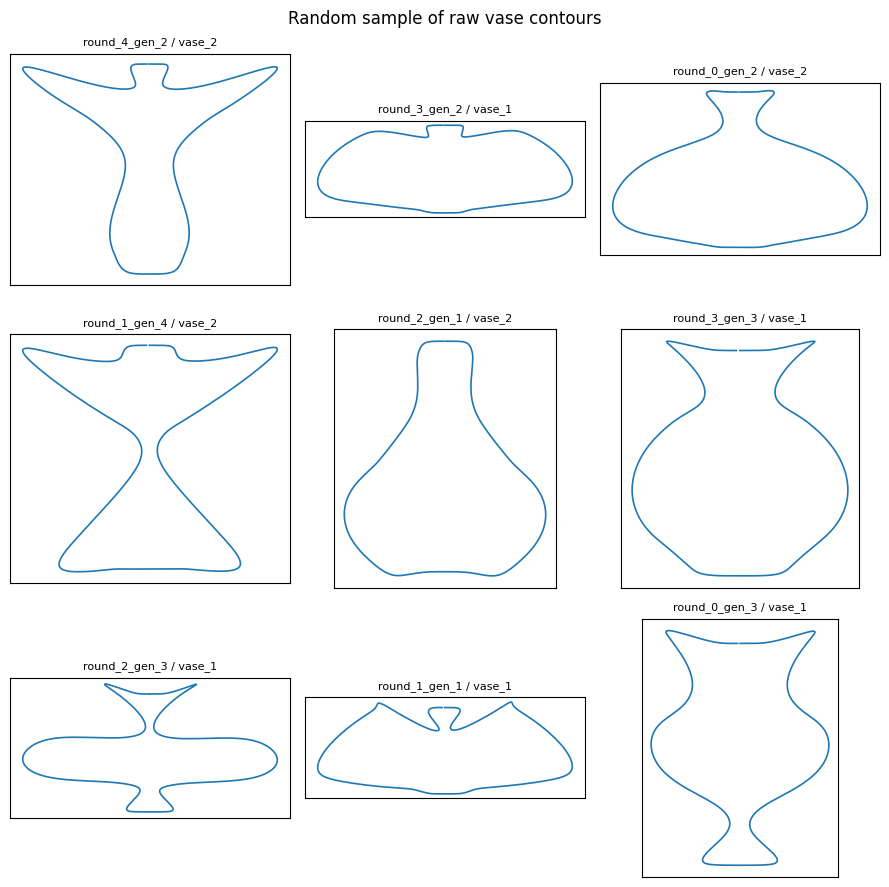

In [4]:
rng = np.random.default_rng(7)
sample_keys = (
    xy_df[GROUP_KEYS]
    .drop_duplicates()
    .sample(9, random_state=7)
    .itertuples(index=False, name=None)
)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, (pid, gk, vase) in zip(axes.flat, sample_keys):
    pts = xy_df.loc[
        (xy_df["participant_id"] == pid) & (xy_df["generation_key"] == gk) & (xy_df["vase"] == vase),
        ["x", "y"],
    ].to_numpy()
    ax.plot(pts[:, 0], pts[:, 1], lw=1.2, color="tab:blue")
    ax.set_aspect("equal")
    ax.set_title(f"{gk} / {vase}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Random sample of raw vase contours")
fig.tight_layout()
plt.show()

## 3. Run feature extraction

One call to `extract_all_features` per vase, in parallel across cores (`joblib`) since the Hübner SRVF comparison dominates runtime. Benchmarked directly on this machine (10 cores): 200 vases in ~9.2s, which scales to **roughly 1.5-2 hours for the full 136,200-vase dataset**. Set `N_VASES` below to a small number first to sanity-check the pipeline before committing to the full run; set it to `None` for the full dataset.

In [5]:
N_VASES = 200  # set to None for the full dataset

META_COLS = [c for c in xy_df.columns if c not in ("x", "y")]

groups = list(xy_df.groupby(GROUP_KEYS, sort=False))
if N_VASES is not None:
    groups = [groups[i] for i in rng.choice(len(groups), size=min(N_VASES, len(groups)), replace=False)]

print(f"Extracting features for {len(groups):,} vases...")


def _extract_one(key, group):
    xy = group[["x", "y"]].to_numpy()
    row = group.iloc[0][META_COLS].to_dict()
    try:
        row.update(fef.extract_all_features(xy, hubner_line4_x=hubner_line4_x))
        row["extraction_error"] = None
    except Exception as e:
        row["extraction_error"] = str(e)
    return row


results = Parallel(n_jobs=-1, verbose=5)(
    delayed(_extract_one)(key, group) for key, group in groups
)

features_df = pd.DataFrame(results)
n_errors = features_df["extraction_error"].notna().sum()
print(f"Done. {len(features_df):,} vases, {n_errors} extraction errors.")
if n_errors:
    print(features_df.loc[features_df["extraction_error"].notna(), GROUP_KEYS + ["extraction_error"]])

Extracting features for 200 vases...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    8.5s


[Parallel(n_jobs=-1)]: Done 140 out of 200 | elapsed:    9.0s remaining:    3.8s


Done. 200 vases, 0 extraction errors.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    9.2s finished


## 4. Assemble output and save

Merge in `distance_from_pc_centroid` (from the separate PC-space source), drop the diagnostic `extraction_error` column used only for the check above, and write one row per vase: every original metadata/demographic column plus the 19 phenotypic features. No `x`/`y` columns, nothing else removed.

In [6]:
output_df = features_df.merge(
    pc_centroid_distance.reset_index(), on=GROUP_KEYS, how="left"
)
output_df = output_df.drop(columns=["extraction_error"])

missing_pc = output_df["distance_from_pc_centroid"].isna().sum()
if missing_pc:
    print(f"Warning: {missing_pc} vases have no matching PC-space record.")

output_df.to_parquet(OUT_PATH, index=False)
print(f"Saved {len(output_df):,} rows x {output_df.shape[1]} columns -> {OUT_PATH}")
output_df.head()

Saved 200 rows x 38 columns -> /Users/joshmt/theperfectpot_analysis/feature_extraction/outdir/vase_phenotype_features.parquet


,generation_key,vase,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,rt_onset_correction_ms,rt_calibration_status,...,contour_autocorrelation,fractal_dimension,position_of_maximum_width,waist_ratio,convexity_ratio,rim_flare_angle,surface_to_volume_ratio,birkhoff_measure,hubner_line4_srvf_distance,distance_from_pc_centroid
0,round_3_gen_3,vase_1,True,True,1.145,1145,1.141,1141.0,4.15,completed,...,1,0.430045,0.308654,0.371081,0.777856,87.982206,2.314704,0.151416,0.506386,4.445578
1,round_3_gen_1,vase_2,True,False,1.138,1138,1.134,1134.0,3.50,completed,...,6,0.549789,0.187841,0.250855,0.948926,49.776449,2.176855,0.020675,0.322766,6.956488
2,round_3_gen_2,vase_2,False,False,4.292,4292,4.276,4276.0,16.50,completed,...,1,0.476550,0.993843,0.617436,0.664611,97.307471,2.824985,0.193825,0.622542,6.440775
3,round_1_gen_2,vase_2,True,False,1.812,1812,1.804,1804.0,8.50,completed,...,2,0.578453,0.044115,0.108157,0.819890,91.743921,1.396550,0.007257,0.462585,9.693138
4,round_2_gen_2,vase_2,False,False,1.501,1501,1.498,1498.0,3.05,completed,...,3,0.496927,0.032874,0.052810,0.598459,94.730017,2.264190,0.048095,0.591724,18.545413


## 5. Sanity checks

In [7]:
FEATURE_COLS = [
    "height_to_width_ratio", "top_to_bottom_area_ratio", "lip_to_belly_ratio", "height",
    "maximum_width", "critical_tipping_angle", "rotational_volume", "total_bending_energy",
    "inflection_count", "contour_autocorrelation", "fractal_dimension",
    "position_of_maximum_width", "waist_ratio", "convexity_ratio", "rim_flare_angle",
    "surface_to_volume_ratio", "birkhoff_measure", "hubner_line4_srvf_distance",
    "distance_from_pc_centroid",
]

print("Null counts (should be 0 outside the PC-centroid warning above):")
print(output_df[FEATURE_COLS].isna().sum()[lambda s: s > 0])

output_df[FEATURE_COLS].describe().T

Null counts (should be 0 outside the PC-centroid warning above):
Series([], dtype: int64)


,count,mean,std,min,25%,50%,75%,max
height_to_width_ratio,200.0,0.963894,0.438785,0.223403,0.644023,0.880457,1.201686,2.456709
top_to_bottom_area_ratio,200.0,1.090595,0.752935,0.240027,0.622348,0.914314,1.347625,6.529376
lip_to_belly_ratio,200.0,0.440073,0.414051,0.000033,0.024664,0.327080,0.932405,1.000000
height,200.0,2.893931,0.870833,0.902192,2.312163,2.826368,3.410508,6.025178
maximum_width,200.0,3.313208,0.987920,1.186760,2.572170,3.286311,3.938888,7.542608
critical_tipping_angle,200.0,23.532145,22.607896,0.000000,0.821040,21.026681,41.074572,83.140912
rotational_volume,200.0,11.475054,7.551687,1.240541,5.465448,9.715331,15.176158,38.513987
total_bending_energy,200.0,8046.093025,26384.370800,41.077757,725.132870,1996.142290,6078.843693,327715.231114
inflection_count,200.0,3.190000,1.464453,0.000000,2.000000,3.000000,4.000000,8.000000
contour_autocorrelation,200.0,2.630000,1.734399,1.000000,1.000000,2.000000,3.000000,9.000000
